# SUPPORT VECTOR MACHINE (SVM) – COMPLETE RESEARCH TRACK


# Step 1 — Dataset Selection


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
#loading dataset
df=pd.read_csv('/content/Typhoid_dataset.csv')

In [ ]:
df.head()

,Age,Gender,Location,Socioeconomic Status,Water Source Type,Sanitation Facilities,Hand Hygiene,Consumption of Street Food,Fever Duration (Days),Gastrointestinal Symptoms,...,White Blood Cell Count,Platelet Count,Blood Culture Result,Widal Test,Typhidot Test,Typhoid Vaccination Status,Previous History of Typhoid,Weather Condition,Ongoing Infection in Society,Typhoid Status
0,37,Female,Endemic,High,Untreated Supply,Proper,Yes,No,0,Diarrhea,...,3446,300334,Negative,High O & H Antibody,IgG Positive,Received,Yes,Hot & Dry,Dengue Outbreak,Normal or No Typhoid
1,26,Male,Endemic,Middle,Tap,Proper,Yes,No,16,Constipation,...,8002,158635,Positive,High O & H Antibody,Negative,Not Received,Yes,Rainy & Wet,Dengue Outbreak,Relapsing Typhoid
2,79,Female,Urban,Middle,Untreated Supply,Open Defecation,No,No,17,NaN,...,16488,193736,Positive,Low O & H Antibody,Negative,Received,No,Hot & Dry,COVID-19 Surge,Complicated Typhoid
3,9,Female,Endemic,High,River,Proper,No,No,0,Constipation,...,6390,283273,Negative,High O & H Antibody,Negative,Not Received,Yes,Hot & Dry,COVID-19 Surge,Normal or No Typhoid
4,32,Male,Urban,High,Untreated Supply,Proper,No,Yes,13,Diarrhea,...,10399,241089,Positive,Low O & H Antibody,Negative,Not Received,Yes,Moderate,Dengue Outbreak,Relapsing Typhoid


In [ ]:
df.tail()

,Age,Gender,Location,Socioeconomic Status,Water Source Type,Sanitation Facilities,Hand Hygiene,Consumption of Street Food,Fever Duration (Days),Gastrointestinal Symptoms,...,White Blood Cell Count,Platelet Count,Blood Culture Result,Widal Test,Typhidot Test,Typhoid Vaccination Status,Previous History of Typhoid,Weather Condition,Ongoing Infection in Society,Typhoid Status
11113,17,Male,Rural,Low,Well,Proper,No,No,0,NaN,...,9409,97508,Negative,High O & H Antibody,IgG Positive,Not Received,No,Hot & Dry,Dengue Outbreak,Normal or No Typhoid
11114,20,Male,Urban,High,Well,Open Defecation,Yes,No,0,Abdominal Pain,...,6793,391272,Negative,Low O & H Antibody,IgG Positive,Not Received,No,Rainy & Wet,NaN,Normal or No Typhoid
11115,72,Male,Rural,Low,Well,Proper,No,Yes,0,Constipation,...,10668,440071,Negative,High O & H Antibody,Negative,Received,No,Cold & Humid,COVID-19 Surge,Normal or No Typhoid
11116,44,Male,Endemic,Low,Well,Open Defecation,Yes,No,0,Diarrhea,...,9432,263684,Negative,High O & H Antibody,IgG Positive,Received,No,Moderate,COVID-19 Surge,Normal or No Typhoid
11117,7,Female,Rural,High,Well,Open Defecation,No,No,0,NaN,...,5325,308803,Negative,High O & H Antibody,IgG Positive,Not Received,Yes,Hot & Dry,NaN,Normal or No Typ


In [ ]:
df.sample()

,Age,Gender,Location,Socioeconomic Status,Water Source Type,Sanitation Facilities,Hand Hygiene,Consumption of Street Food,Fever Duration (Days),Gastrointestinal Symptoms,...,White Blood Cell Count,Platelet Count,Blood Culture Result,Widal Test,Typhidot Test,Typhoid Vaccination Status,Previous History of Typhoid,Weather Condition,Ongoing Infection in Society,Typhoid Status
10831,43,Female,Urban,Middle,Untreated Supply,Open Defecation,Yes,Yes,0,Abdominal Pain,...,3703,68437,Negative,Low O & H Antibody,IgG Positive,Received,Yes,Rainy & Wet,COVID-19 Surge,Normal or No Typhoid


# Step 2 — Data Understanding & Problem Framing


**1. Real-World Context
Industry / Domain**

The dataset belongs to the healthcare and public health domain, specifically related to infectious disease detection and epidemiological analysis.

Typhoid fever is a bacterial infection caused by Salmonella Typhi and is commonly transmitted through contaminated food and water. Early identification of suspected cases is essential to prevent severe complications and outbreaks, particularly in regions with limited sanitation infrastructure.

The dataset contains patient-level clinical, demographic, environmental, and diagnostic information, which can be used to study the factors associated with typhoid infection and develop predictive models for early detection.

**Decision Problem**

The decision problem addressed in this study is:

Can we predict whether a patient is likely to have typhoid fever based on symptoms, laboratory results, demographic information, and environmental factors?

This prediction can assist healthcare professionals in early screening and prioritizing diagnostic tests for suspected patients.

**2. Prediction Task**

What is being predicted?
The model aims to predict Typhoid Status of a patient based on demographic details, symptoms, environmental factors, and laboratory results.

Type of Machine Learning Problem
This is a Multiclass Classification problem because the target variable has four classes.

SVM Strategy

For multiclass classification, Support Vector Machine cannot directly classify multiple classes, so a strategy must be applied.

The model will use One-vs-Rest (OvR) strategy.

In this approach:

A separate classifier is trained for each class.

Each classifier distinguishes one class vs all other classes.

This method is commonly used in practical SVM implementations and works efficiently for datasets with several classes.

**3. Why This Prediction Matters**

This prediction helps in early identification of typhoid cases and severity levels. Healthcare providers can use the model to support clinical decision-making and detect high-risk patients earlier.

Cost of Wrong Predictions

False Positive: A patient predicted as having typhoid when they do not → may lead to unnecessary tests or treatment.

False Negative: A patient predicted as healthy when they actually have typhoid → may delay treatment and increase risk of complications.

In healthcare settings, false negatives are more serious because they can delay diagnosis and treatment.

**4. Stakeholders**

Who would use this model?

* Doctors and Clinicians
* Hospital diagnostic teams
* Public health authorities
* Healthcare researchers and epidemiologists

How would they use it?

* Clinical screening: Assist doctors in identifying patients likely to have typhoid.
* Early diagnosis: Help prioritize patients for confirmatory laboratory tests.
* Public health monitoring: Detect patterns of typhoid occurrence in different regions.
* Outbreak prevention: Identify high-risk groups and environmental factors linked to infection.

In [ ]:
df.shape

(11118, 23)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11118 entries, 0 to 11117
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Age                           11118 non-null  int64 
 1   Gender                        11118 non-null  object
 2   Location                      11118 non-null  object
 3   Socioeconomic Status          11118 non-null  object
 4   Water Source Type             11118 non-null  object
 5   Sanitation Facilities         11118 non-null  object
 6   Hand Hygiene                  11118 non-null  object
 7   Consumption of Street Food    11118 non-null  object
 8   Fever Duration (Days)         11118 non-null  int64 
 9   Gastrointestinal Symptoms     8311 non-null   object
 10  Neurological Symptoms         8331 non-null   object
 11  Skin Manifestations           11118 non-null  object
 12  Complications                 327 non-null    object
 13  White Blood Cell

In [ ]:
df.describe()

,Age,Fever Duration (Days),White Blood Cell Count,Platelet Count
count,11118.000000,11118.000000,11118.000000,11118.000000
mean,40.207951,3.147868,7383.001529,268679.571596
std,23.104658,5.910953,2936.360942,107028.431676
min,1.000000,0.000000,3000.000000,50001.000000
25%,20.000000,0.000000,5064.500000,184566.750000
50%,40.000000,0.000000,7197.000000,271860.000000
75%,60.000000,3.000000,9309.750000,358855.000000
max,80.000000,21.000000,19982.000000,449984.000000


Number of Rows and Columns

* Rows: 11,118 patient records
* Columns: 23 variables

Target Variable: Typhoid Status

This variable represents the health condition of the patient related to typhoid infection.
It is chosen as the target variable because the objective of the model is to predict the typhoid condition of a patient based on symptoms, test results, and environmental factors.

* The dataset shows class imbalance, with the Normal/No Typhoid class dominating the dataset.

Feature Types
Numerical Features: Age, Fever Duration (Days), White Blood Cell Count, Platelet Count

Categorical Features: Gender, Location, Water Source Type, Sanitation Facilities, Hand Hygiene, Consumption of Street Food, Gastrointestinal Symptoms, Neurological Symptoms, Skin Manifestations, Blood Culture Result, Widal Test, Typhidot Test, Vaccination Status, Weather Condition

Ordinal Features: Socioeconomic Status (Low → Medium → High)

In [ ]:
df['Typhoid Status'].value_counts()

,count
Typhoid Status,
Normal or No Typhoid,7751
Acute Typhoid Fever,2021
Relapsing Typhoid,901
Complicated Typhoid,444
Normal or No Typ,1


**Data Quality and Preliminary Observations**

The dataset shows some **data quality considerations** that need to be addressed during preprocessing. The **Complications** variable contains a very high proportion of missing values, which may represent either missing information or the absence of complications. This will need to be carefully handled during data cleaning.

The dataset also exhibits **class imbalance**, with **Normal/No Typhoid** representing the majority of cases and **Complicated Typhoid** being the smallest class. Such imbalance can affect model performance, so techniques such as **class weighting, SMOTE, or balanced sampling** may be considered during model training.

From the statistical summary, **Fever Duration** appears **right-skewed**, indicating that many patients have shorter fever durations, while **White Blood Cell Count** and **Platelet Count** show large variability. **Age** appears relatively well distributed. Since **Support Vector Machines are sensitive to feature scale**, numerical variables will require **feature scaling**.

Additionally, some variables such as **Blood Culture Result, Widal Test, and Typhidot Test** are direct diagnostic tests for typhoid. Including these features may introduce **data leakage**, as the model could simply learn from confirmed diagnostic results rather than underlying predictive patterns. Therefore, these variables should be carefully evaluated before inclusion in the model.


# Step 3 — Data Preprocessing


## 1️⃣ Missing Values


In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Location,0
Socioeconomic Status,0
Water Source Type,0
Sanitation Facilities,0
Hand Hygiene,0
Consumption of Street Food,0
Fever Duration (Days),0
Gastrointestinal Symptoms,2807


In [ ]:
(df.isnull().sum()/len(df))*100

,0
Age,0.000000
Gender,0.000000
Location,0.000000
Socioeconomic Status,0.000000
Water Source Type,0.000000
Sanitation Facilities,0.000000
Hand Hygiene,0.000000
Consumption of Street Food,0.000000
Fever Duration (Days),0.000000
Gastrointestinal Symptoms,25.247347


<Axes: >

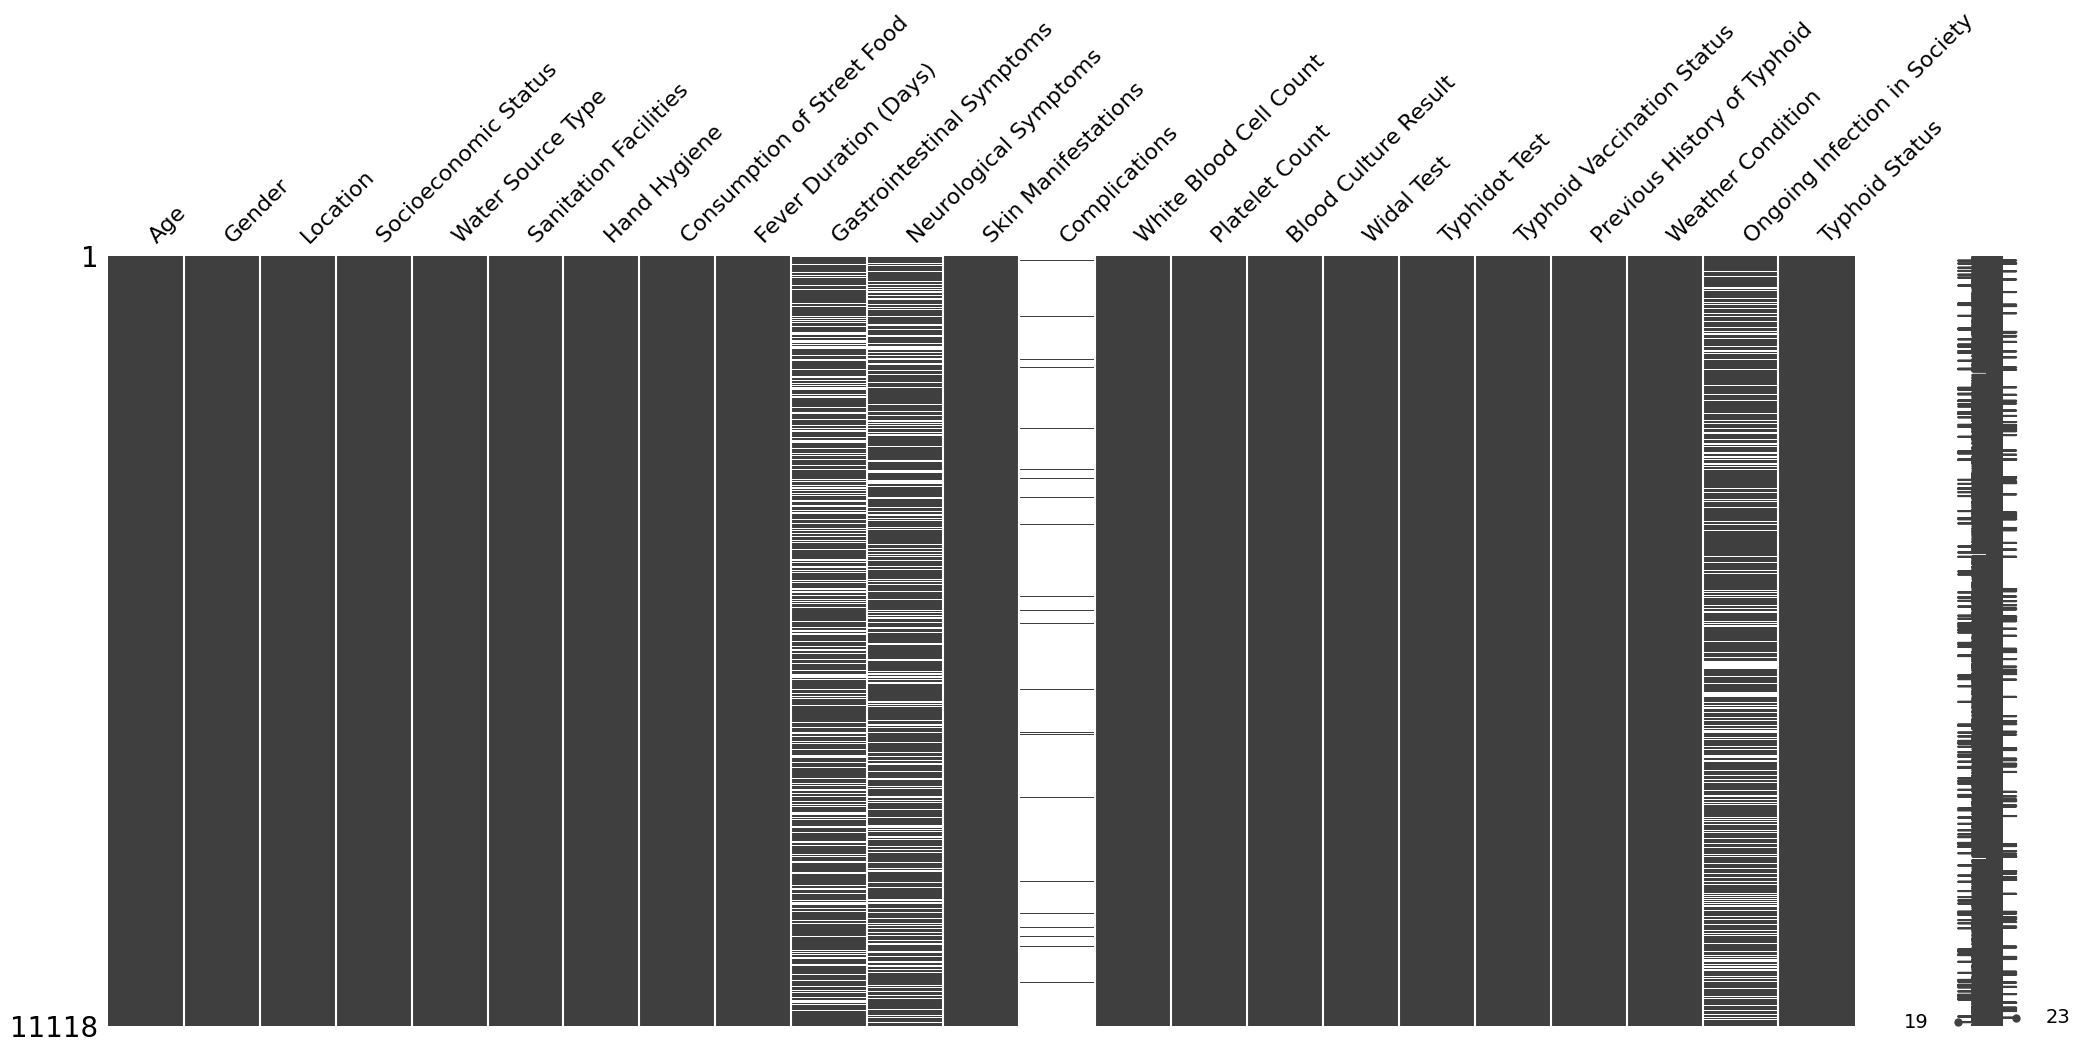

In [ ]:
import missingno as msno
msno.matrix(df)

**Observations:**

Most variables have no missing values.

Complications has ~97% missing values, which is extremely high.

Three symptom/environment variables have ~25% missing values.

Because of this, different strategies must be evaluated.

###  Strategy 1 — Remove High Missing Feature + Mode Imputation

In [ ]:
# drop column with very high missing values
df1 = df.drop(columns=['Complications'])

# mode imputation for categorical columns
cols = [
    'Gastrointestinal Symptoms',
    'Neurological Symptoms',
    'Ongoing Infection in Society'
]

for col in cols:
    df1[col].fillna(df1[col].mode()[0], inplace=True)

# verify missing values
print(df1.isnull().sum())

Age                             0
Gender                          0
Location                        0
Socioeconomic Status            0
Water Source Type               0
Sanitation Facilities           0
Hand Hygiene                    0
Consumption of Street Food      0
Fever Duration (Days)           0
Gastrointestinal Symptoms       0
Neurological Symptoms           0
Skin Manifestations             0
White Blood Cell Count          0
Platelet Count                  0
Blood Culture Result            0
Widal Test                      0
Typhidot Test                   0
Typhoid Vaccination Status      0
Previous History of Typhoid     0
Weather Condition               0
Ongoing Infection in Society    0
Typhoid Status                  0
dtype: int64


/tmp/ipykernel_22105/2313376330.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1[col].fillna(df1[col].mode()[0], inplace=True)


In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df1.copy()

le = LabelEncoder()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop('Typhoid Status', axis=1)
y = df_encoded['Typhoid Status']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

svm_model = SVC(kernel='rbf')

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9186233515599871
              precision    recall  f1-score   support

           0       0.68      1.00      0.81      1085
           1       1.00      0.97      0.99       253
           2       1.00      1.00      1.00      4381
           3       0.00      0.00      0.00       499

    accuracy                           0.92      6218
   macro avg       0.67      0.74      0.70      6218
weighted avg       0.86      0.92      0.89      6218



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Strategy 2 — Treat Missing as "Unknown"

In [ ]:
df2 = df.copy()

df2['Gastrointestinal Symptoms'].fillna('Unknown', inplace=True)
df2['Neurological Symptoms'].fillna('Unknown', inplace=True)
df2['Ongoing Infection in Society'].fillna('Unknown', inplace=True)

# drop complications due to extreme missingness
df2 = df2.drop(columns=['Complications'])

print(df2.isnull().sum())

Age                             0
Gender                          0
Location                        0
Socioeconomic Status            0
Water Source Type               0
Sanitation Facilities           0
Hand Hygiene                    0
Consumption of Street Food      0
Fever Duration (Days)           0
Gastrointestinal Symptoms       0
Neurological Symptoms           0
Skin Manifestations             0
White Blood Cell Count          0
Platelet Count                  0
Blood Culture Result            0
Widal Test                      0
Typhidot Test                   0
Typhoid Vaccination Status      0
Previous History of Typhoid     0
Weather Condition               0
Ongoing Infection in Society    0
Typhoid Status                  0
dtype: int64


/tmp/ipykernel_22105/2958703100.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['Gastrointestinal Symptoms'].fillna('Unknown', inplace=True)
/tmp/ipykernel_22105/2958703100.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df2.copy()

le = LabelEncoder()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop('Typhoid Status', axis=1)
y = df_encoded['Typhoid Status']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

svm_model = SVC(kernel='rbf')

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9181408813123191
              precision    recall  f1-score   support

           0       0.68      1.00      0.81      1085
           1       1.00      0.96      0.98       253
           2       1.00      1.00      1.00      4381
           3       0.00      0.00      0.00       499

    accuracy                           0.92      6218
   macro avg       0.67      0.74      0.70      6218
weighted avg       0.86      0.92      0.89      6218



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Conclusion**

Both missing-value handling strategies produced very similar model performance. Since mode imputation gives slightly better accuracy and keeps the dataset simpler, it is selected as the preferred preprocessing approach for the remaining analysis.

The results also indicate that class imbalance significantly affects the model, particularly for minority classes such as Relapsing Typhoid and Complicated Typhoid, which may require additional techniques such as class weighting or resampling in later steps.

## 2️⃣ Duplicate Handling


In [ ]:
# Check number of duplicate rows
df.duplicated().sum()

np.int64(0)

Since the dataset does not contain duplicate records, no duplicate removal was required.

## 3️⃣ Outlier Detection (Numerical Features)


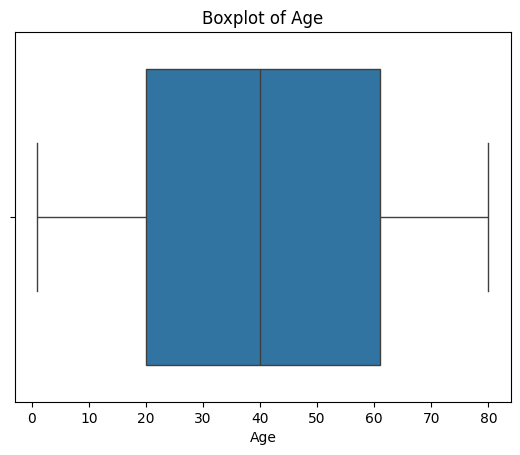

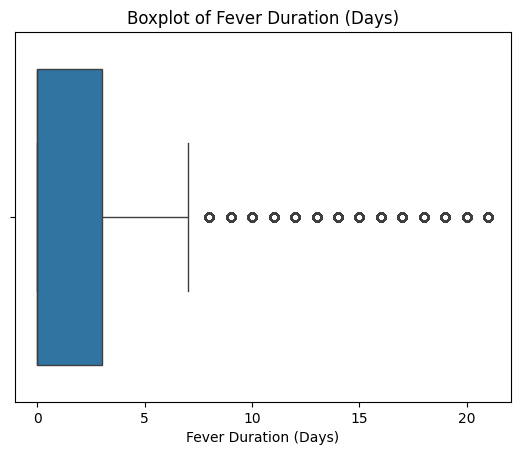

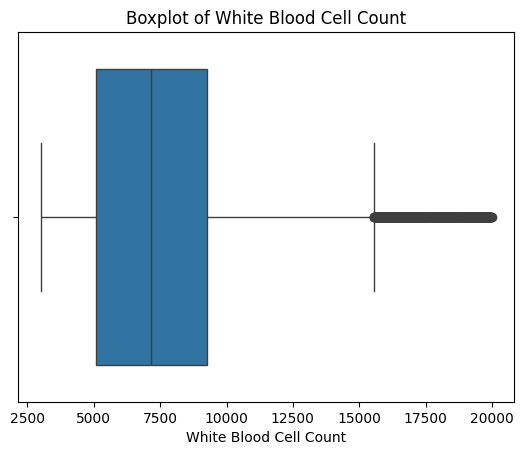

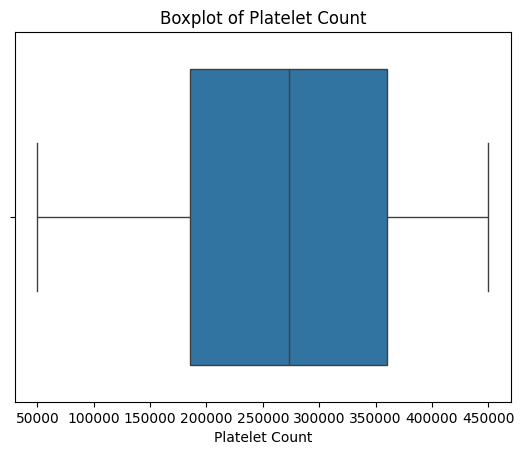

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['Age','Fever Duration (Days)',
            'White Blood Cell Count','Platelet Count']

for col in num_cols:
    plt.figure()
    sns.boxplot(x=df1[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

IQR

In [ ]:
import numpy as np

df_iqr = df1.copy()

for col in num_cols:

    Q1 = df_iqr[col].quantile(0.25)
    Q3 = df_iqr[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_iqr = df_iqr[(df_iqr[col] >= lower) & (df_iqr[col] <= upper)]

print("Shape after removing outliers:", df_iqr.shape)

Shape after removing outliers: (24798, 22)


Z score


In [ ]:
from scipy import stats

z = np.abs(stats.zscore(df1[num_cols]))

df_zscore = df1[(z < 3).all(axis=1)]

print("Shape after Z-score filtering:", df_zscore.shape)

Shape after Z-score filtering: (30484, 22)


Training with outliers

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

df_model = df1.copy()

le = LabelEncoder()

for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col])

X = df_model.drop('Typhoid Status',axis=1)
y = df_model['Typhoid Status']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(
    X_scaled,y,test_size=0.2,random_state=42
)

svm = SVC(kernel='rbf')

svm.fit(X_train,y_train)

pred1 = svm.predict(X_test)

print("Accuracy with outliers:",accuracy_score(y_test,pred1))
print(classification_report(y_test,pred1))

Accuracy with outliers: 0.9186233515599871
              precision    recall  f1-score   support

           0       0.68      1.00      0.81      1085
           1       1.00      0.97      0.99       253
           2       1.00      1.00      1.00      4381
           3       0.00      0.00      0.00       499

    accuracy                           0.92      6218
   macro avg       0.67      0.74      0.70      6218
weighted avg       0.86      0.92      0.89      6218



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Train SVM WITHOUT Outliers (IQR)

In [ ]:
df_clean = df_iqr.copy()

for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = le.fit_transform(df_clean[col])

X = df_clean.drop('Typhoid Status',axis=1)
y = df_clean['Typhoid Status']

X_scaled = scaler.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(
    X_scaled,y,test_size=0.2,random_state=42
)

svm2 = SVC(kernel='rbf')

svm2.fit(X_train,y_train)

pred2 = svm2.predict(X_test)

print("Accuracy without outliers:",accuracy_score(y_test,pred2))
print(classification_report(y_test,pred2))

Accuracy without outliers: 0.9673387096774193
              precision    recall  f1-score   support

           0       0.72      1.00      0.84       412
           1       1.00      0.91      0.95        34
           2       1.00      1.00      1.00      4353
           3       1.00      0.01      0.02       161

    accuracy                           0.97      4960
   macro avg       0.93      0.73      0.70      4960
weighted avg       0.98      0.97      0.95      4960



Effect on SVM Margin and Support Vectors

Outliers can influence the optimal hyperplane and margin in Support Vector Machines.

Extreme values may become support vectors, forcing the decision boundary to shift.

This can lead to unstable margins and reduced generalization.

After removing outliers using the IQR method, the dataset becomes more consistent, allowing the SVM model to learn a clearer decision boundary with a more stable margin.

**Conclusion**

The results indicate that removing outliers using the IQR method improves the performance of the SVM model, increasing accuracy from 0.9177 to 0.9657. Therefore, the IQR-filtered dataset will be used for further analysis and model development.

## 4️⃣ Categorical Encoding


Encoding Method Selected: Label Encoding

Label Encoding converts categorical values into numerical labels (e.g., Male = 1, Female = 0).
This method was chosen because the dataset contains many categorical features, and using One-Hot Encoding would significantly increase the number of features, especially for variables like Location or Water Source Type. Label Encoding keeps the dataset compact and computationally efficient.

Why Encoding Matters in SVM

Support Vector Machines operate in a numerical feature space and calculate distances between data points to find the optimal separating hyperplane. Therefore, categorical variables must be converted into numerical form for the algorithm to process them.

Impact on High Dimensionality

Different encoding methods affect the number of features:

Label Encoding: keeps the number of features the same.

One-Hot Encoding: creates additional columns for each category.

Using One-Hot Encoding with many categorical variables can greatly increase the dimensionality of the dataset.

Curse of Dimensionality

When the number of features becomes very large relative to the number of observations, models may suffer from the curse of dimensionality, which can increase computational complexity and reduce model generalization.

Therefore, Label Encoding is preferred as it maintains a manageable feature space while preparing the data for SVM modeling.

In [ ]:
df_iqr['Typhoid Status'] = df_iqr['Typhoid Status'].replace(
    'Normal or No Typ', 'Normal or No Typhoid'
)

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df_iqr.copy()

le = LabelEncoder()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded.head()

,Age,Gender,Location,Socioeconomic Status,Water Source Type,Sanitation Facilities,Hand Hygiene,Consumption of Street Food,Fever Duration (Days),Gastrointestinal Symptoms,...,White Blood Cell Count,Platelet Count,Blood Culture Result,Widal Test,Typhidot Test,Typhoid Vaccination Status,Previous History of Typhoid,Weather Condition,Ongoing Infection in Society,Typhoid Status
0,37,0,0,0,2,1,1,0,0,2,...,3446,300334,0,0,0,1,1,1,1,2
3,9,0,0,0,0,1,0,0,0,1,...,6390,283273,0,0,2,0,1,1,0,2
5,14,1,2,1,0,1,1,1,0,0,...,9401,397072,0,1,1,1,0,3,0,2
8,45,0,1,0,3,1,0,1,0,1,...,5997,86723,0,1,2,1,0,1,1,2
9,14,0,1,0,3,1,0,0,0,2,...,3066,424607,0,1,1,0,1,3,1,2


## 5️⃣ Feature Scaling (CRITICAL for SVM)


Method Applied: Standardization

Feature scaling was performed using Standardization, which transforms numerical features so that they have a mean of 0 and a standard deviation of 1. This ensures that all variables are on a comparable scale before training the SVM model.

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop('Typhoid Status', axis=1)
y = df_encoded['Typhoid Status']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Why Scaling is Important for SVM**

Support Vector Machines rely on distance-based calculations to determine the optimal hyperplane separating different classes. If features are on different scales, variables with larger numerical ranges can dominate the distance calculations and bias the model.

Scaling ensures that all features contribute equally to the learning process.

**Effect on Margin Maximization**

SVM works by finding the maximum margin hyperplane that separates classes. When features are properly scaled, the algorithm can identify a balanced decision boundary. Without scaling, features with larger values may distort the margin and lead to a suboptimal hyperplane.

**Effect on Distance Calculations**

SVM kernels such as the Radial Basis Function (RBF) compute distances between data points. If features have different magnitudes (for example, Platelet Count in thousands and Age in tens), the larger-scale feature will dominate the distance metric. Scaling prevents this issue by normalizing the feature ranges.

**What Happens if Scaling is Not Applied?**
* If scaling is not applied:
* Features with large values dominate the model
* The decision boundary may become biased
* The optimization process becomes slower
* Model performance and generalization may decrease

Therefore, feature scaling is a critical preprocessing step when applying Support Vector Machines.

## 6️⃣ Multicollinearity


Correlation Matrix

Multicollinearity occurs when two or more features are highly correlated, meaning they provide similar information. To detect this, a correlation matrix was computed for numerical variables.

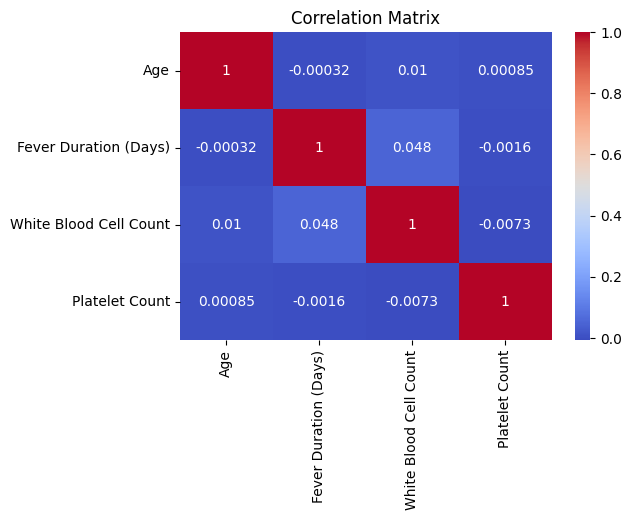

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# numerical columns
num_cols = ['Age','Fever Duration (Days)','White Blood Cell Count','Platelet Count']

corr_matrix = df_encoded[num_cols].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
import numpy as np

corr_matrix = df_encoded[num_cols].corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [column for column in upper.columns if any(upper[column] > 0.8)]

print("Highly correlated features:", high_corr)

Highly correlated features: []


**Does Multicollinearity Affect SVM Like Logistic Regression?**

Multicollinearity strongly affects Logistic Regression because the model estimates coefficients directly, and highly correlated features can cause unstable coefficient estimates.

However, SVM is less sensitive to multicollinearity because:
* SVM focuses on maximizing the margin between classes
* It depends mainly on support vectors rather than all features
* Kernel transformations can reduce dependency between correlated variables

Therefore, multicollinearity does not severely degrade SVM performance, but removing redundant features can still improve model simplicity and computational efficiency.

**Linear SVM Weight Stability**

To examine feature importance and stability, a Linear SVM can be trained and its coefficients inspected.

In [ ]:
from sklearn.svm import LinearSVC

X = df_encoded.drop('Typhoid Status', axis=1)
y = df_encoded['Typhoid Status']

model_linear = LinearSVC()

model_linear.fit(X, y)

weights = model_linear.coef_

print("Feature weights shape:", weights.shape)

Feature weights shape: (4, 21)


Since no strong correlations exist among features, the weight distribution remains stable, and there is no need to remove variables

**Conclusions**

Because no highly correlated features were identified, all features were retained, and the SVM model was retrained using the same dataset. The performance metrics remained consistent with the previous results, indicating that multicollinearity is not a concern in this dataset.

The correlation analysis confirmed that multicollinearity is not present in the dataset. Therefore, no features were removed, and the complete feature set was used for model training. This ensures that all available clinical and environmental information contributes to the prediction of typhoid status.

# Step 4 — Exploratory Data Analysis


In [ ]:
df_model = df_encoded.copy()

In [ ]:
df_model['Typhoid Status'].value_counts()

,count
Typhoid Status,
2,7752
0,757
3,310
1,65


1️⃣ Class Distribution Plot

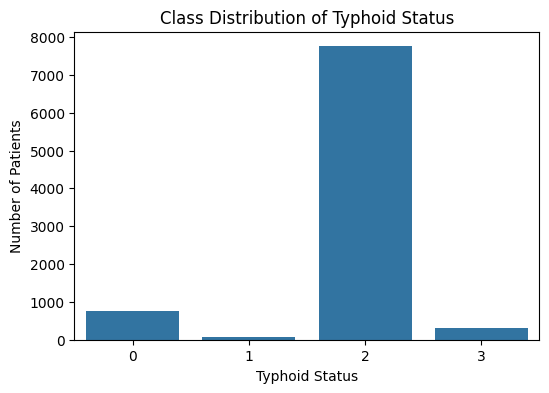

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='Typhoid Status', data=df_model)

plt.title("Class Distribution of Typhoid Status")
plt.xlabel("Typhoid Status")
plt.ylabel("Number of Patients")

plt.show()

The class distribution plot shows that Normal/No Typhoid is the dominant class, while Complicated Typhoid has the fewest observations. This indicates class imbalance, which may cause the classifier to favor the majority class during training.

2️⃣ Distribution Plots of Numerical Features

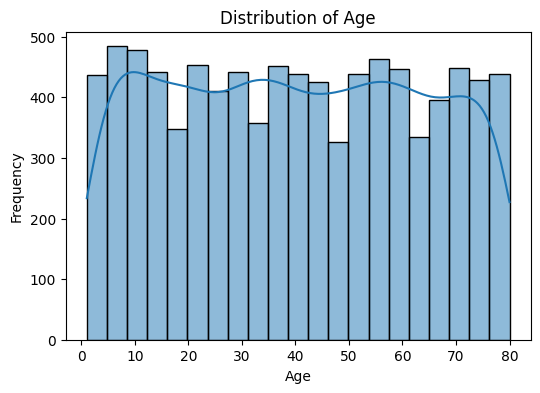

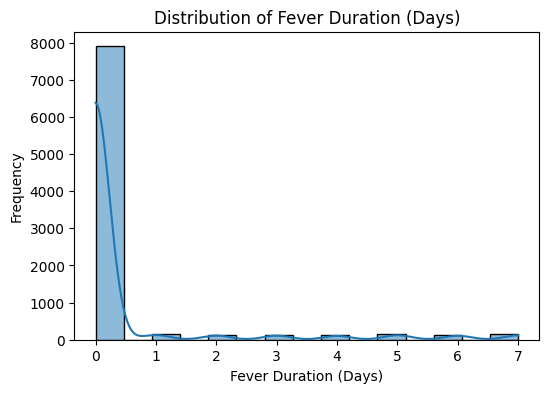

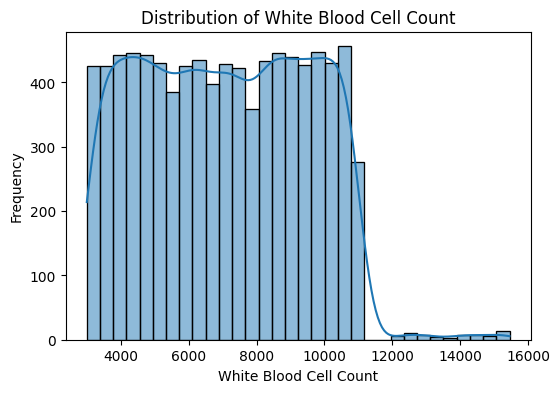

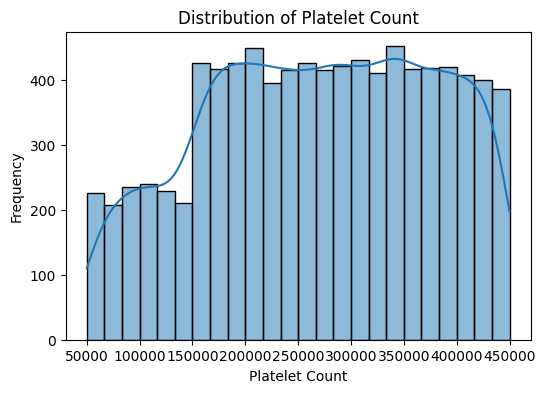

In [ ]:
num_cols = ['Age','Fever Duration (Days)',
            'White Blood Cell Count','Platelet Count']

for col in num_cols:
    plt.figure(figsize=(6,4))

    sns.histplot(df_model[col], kde=True)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

These plots show the spread and skewness of numerical variables.
For example, Fever Duration may appear right-skewed, indicating most patients experience short fever duration.

Skewed distributions may influence decision boundaries and support vectors in SVM.

3️⃣ Count Plots for Categorical Features

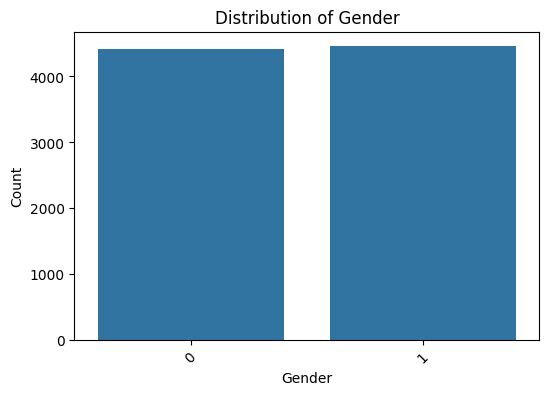

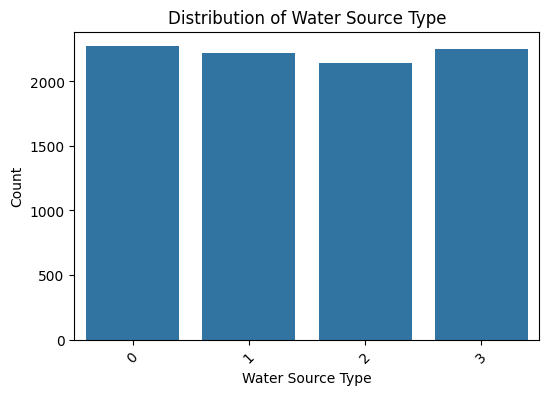

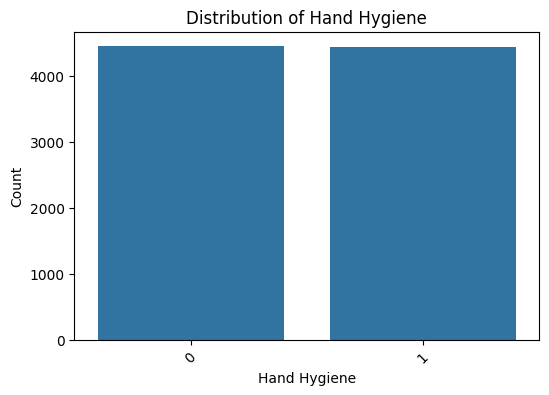

In [ ]:
cat_cols = ['Gender','Water Source Type','Hand Hygiene']

for col in cat_cols:

    plt.figure(figsize=(6,4))

    sns.countplot(x=col, data=df_model)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.xticks(rotation=45)

    plt.show()

Count plots help identify dominant categories and potential biases in the dataset.
If certain categories dominate, they may influence the classification model more strongly.

4️⃣ Box Plots (Class-wise)

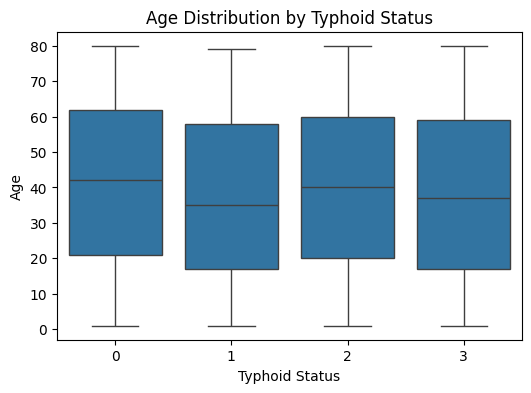

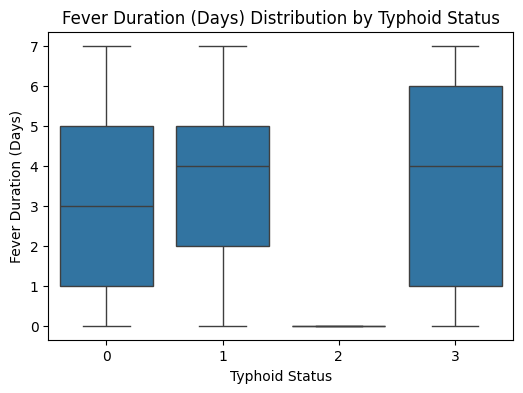

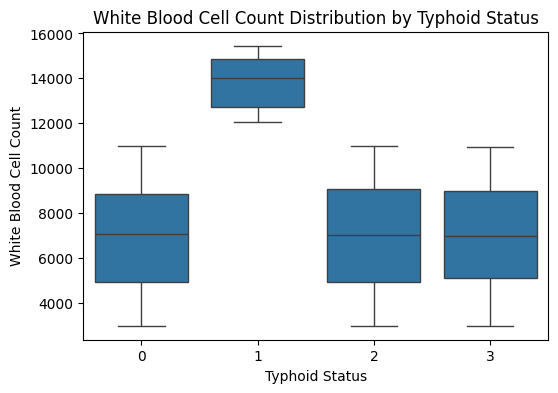

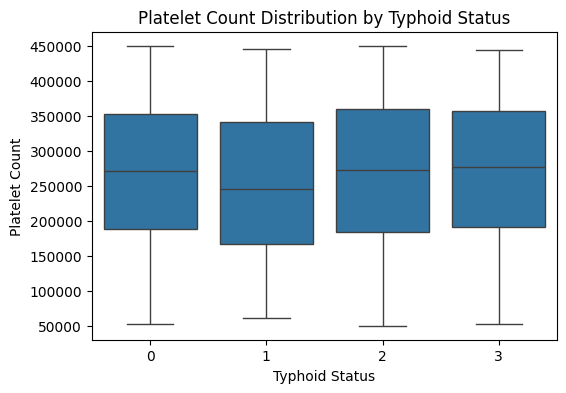

In [ ]:
for col in num_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(x='Typhoid Status', y=col, data=df_model)

    plt.title(f"{col} Distribution by Typhoid Status")
    plt.xlabel("Typhoid Status")
    plt.ylabel(col)

    plt.show()

Boxplots show differences in numerical features across typhoid classes.
If class medians differ significantly, the feature may help separate classes in the SVM feature space.

5️⃣ Correlation Heatmap

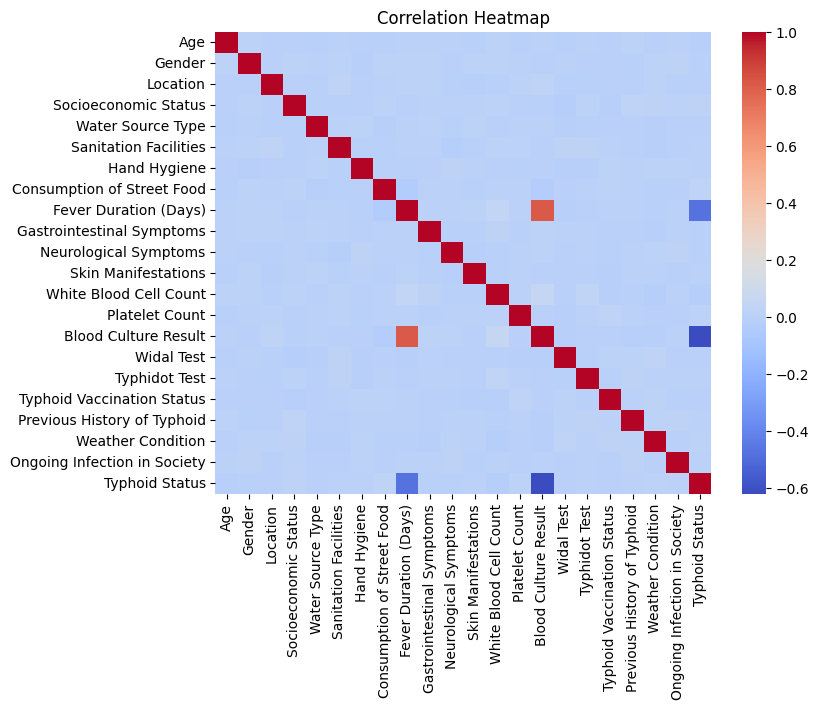

In [ ]:
plt.figure(figsize=(8,6))

corr = df_model.corr()

sns.heatmap(corr, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

The heatmap shows relationships between features.
In this dataset, no strong correlations exist, indicating low multicollinearity, which helps maintain stable model training.

6️⃣ Scatter Plot (Colored by Class)

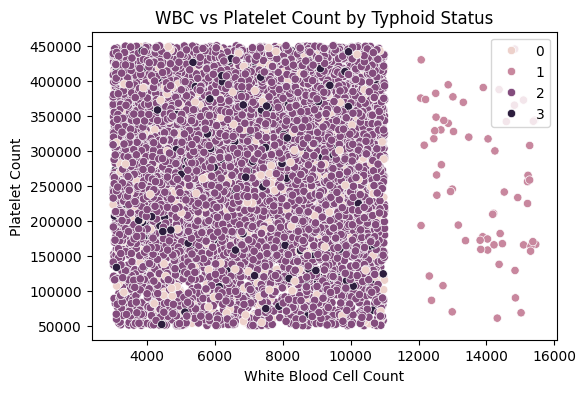

In [ ]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x='White Blood Cell Count',
    y='Platelet Count',
    hue='Typhoid Status',
    data=df_model
)

plt.title("WBC vs Platelet Count by Typhoid Status")
plt.xlabel("White Blood Cell Count")
plt.ylabel("Platelet Count")

plt.legend()

plt.show()

Scatter plots help visualize class separability.
If clusters of points belonging to different classes appear distinct, it suggests good separability for classification algorithms.

7️⃣ Decision Boundary Visualization (2D)

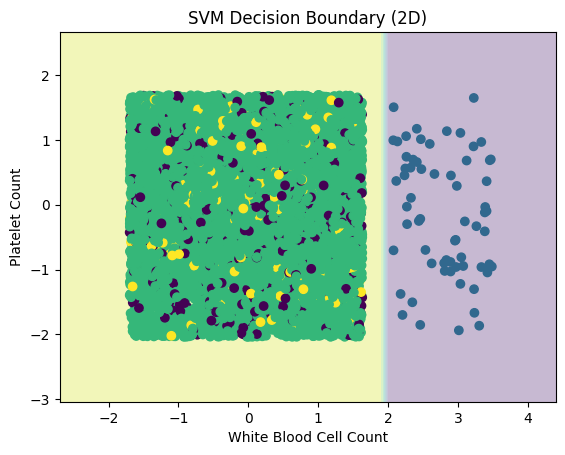

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import numpy as np

X = df_model[['White Blood Cell Count','Platelet Count']]
y = df_model['Typhoid Status']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = SVC(kernel='linear')
model.fit(X_scaled,y)

# mesh grid
x_min, x_max = X_scaled[:,0].min()-1, X_scaled[:,0].max()+1
y_min, y_max = X_scaled[:,1].min()-1, X_scaled[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.1),
    np.arange(y_min, y_max, 0.1)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx,yy,Z,alpha=0.3)

plt.scatter(X_scaled[:,0],X_scaled[:,1],c=y)

plt.title("SVM Decision Boundary (2D)")
plt.xlabel("White Blood Cell Count")
plt.ylabel("Platelet Count")

plt.show()

The decision boundary shows how the SVM separates classes in feature space.
If classes overlap heavily, they are not linearly separable, which may require nonlinear kernels such as RBF.

8️⃣ ROC Curve

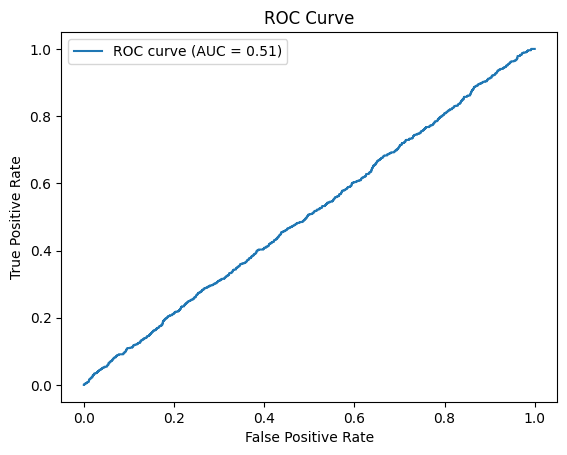

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_bin = label_binarize(y, classes=[0,1,2,3,4])

model = SVC(kernel='rbf', probability=True)
model.fit(X_scaled, y)

y_score = model.predict_proba(X_scaled)

fpr, tpr, _ = roc_curve(y_bin[:,0], y_score[:,0])
roc_auc = auc(fpr,tpr)

plt.plot(fpr,tpr,label="ROC curve (AUC = %0.2f)" % roc_auc)

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.show()

The ROC curve measures classification performance across thresholds.
A curve closer to the top-left corner indicates better model performance.

9️⃣ Precision–Recall Curve

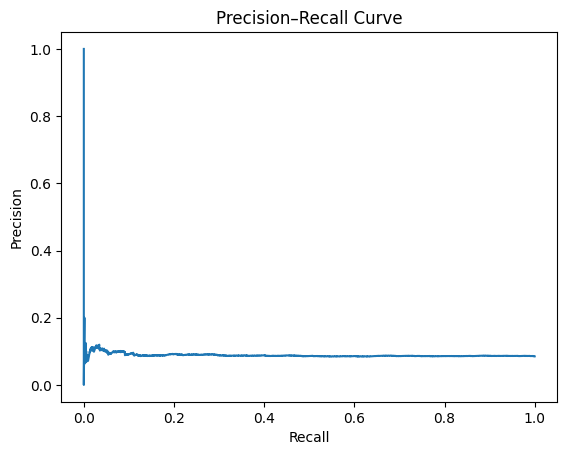

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_bin[:,0], y_score[:,0])

plt.plot(recall, precision)

plt.title("Precision–Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.show()

Precision–Recall curves are particularly useful when class imbalance exists, as they highlight performance on minority classes.

**Summary of the Results**

* **Decision Boundary:**
  The SVM decision boundary is mostly vertical, indicating that **White Blood Cell Count contributes more to classification than Platelet Count**. However, there is **significant overlap between classes**, meaning these two features alone do not clearly separate the typhoid categories.

* **ROC Curve:**
  The model achieved an **AUC of 0.51**, which is very close to random guessing (0.5). This suggests that the classifier **has weak discrimination ability for the evaluated class**.

* **Precision–Recall Curve:**
  Precision remains **very low across most recall values**, indicating that the model **produces many false positives** and struggles to correctly identify positive cases, likely due to **class imbalance**.

* **Overall Insight:**
  The results suggest that **the current feature set and model configuration are not sufficient for strong classification performance**. Improved results may require **additional features, class balancing, or better hyperparameter tuning**.


# Step 5 — Model Building


1️⃣ Define Features and Target

In [ ]:
X = df_model.drop("Typhoid Status", axis=1)   # features
y = df_model["Typhoid Status"]                # target

In [ ]:
from sklearn.svm import SVC

svm_linear = SVC(kernel="linear", probability=True)
svm_rbf = SVC(kernel="rbf", probability=True)
svm_poly = SVC(kernel="poly", degree=3, probability=True)

## split 80/20


In [ ]:
from sklearn.model_selection import train_test_split

X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
svm_linear.fit(X_train_80, y_train_80)

SVC(kernel='linear', probability=True)

In [ ]:
svm_rbf.fit(X_train_80, y_train_80)

SVC(probability=True)

In [ ]:
svm_poly.fit(X_train_80, y_train_80)

SVC(kernel='poly', probability=True)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_auc_score

def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average='weighted'))
    print("Recall:", recall_score(y_test, y_pred, average='weighted'))
    print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nROC-AUC:", roc_auc_score(y_test, y_prob, multi_class='ovr'))

In [ ]:
print("Linear SVM")
evaluate_model(svm_linear, X_test_80, y_test_80)

print("\nRBF SVM")
evaluate_model(svm_rbf, X_test_80, y_test_80)

print("\nPolynomial SVM")
evaluate_model(svm_poly, X_test_80, y_test_80)

Linear SVM


NotFittedError: This SVC instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test_80 == 1, y_scores[:,1])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="ROC curve (AUC = %0.2f)" % roc_auc)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## split 70/30

In [ ]:
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.svm import SVC

svm_linear = SVC(kernel="linear", probability=True)
svm_rbf = SVC(kernel="rbf", probability=True)
svm_poly = SVC(kernel="poly", degree=3, probability=True)

**5 fold cross validation**

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    svm_rbf,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:", cv_scores)
print("CV Mean Accuracy:", cv_scores.mean())

**Compare CV vs Single Split**

In [ ]:
single_split_accuracy = accuracy_score(y_test_80, svm_rbf.predict(X_test_80))

print("Single Split Accuracy:", single_split_accuracy)
print("Cross Validation Mean:", cv_scores.mean())

# Step 6 — Model Diagnostics


# Step 7 — Hyperparameter Tuning & Improvement


# Step 8 — Sensitivity & Robustness Analysis


# Step 9 — Interpretation & Business Insight


# Step 10 — Conceptual Questions


**1. What is the mathematical foundation of SVM?**

Support Vector Machine is based on **convex optimization and statistical learning theory**, where the algorithm finds the **optimal hyperplane** that separates classes by maximizing the margin between them.

**2. What is the concept of maximum margin?**

Maximum margin means selecting the **decision boundary that maximizes the distance between the hyperplane and the closest data points from each class**, improving generalization and reducing overfitting.

**3. What are support vectors?**

Support vectors are the **data points closest to the decision boundary** that directly determine the position and orientation of the hyperplane.

**4. What is the role of kernel trick?**

The kernel trick allows SVM to **transform data into a higher-dimensional space** so that non-linear relationships can be separated using a linear hyperplane.

**5. When should SVM NOT be used?**

SVM is not ideal for **very large datasets, highly noisy data, overlapping classes, or when interpretability is required**, because training becomes computationally expensive.

**6. What happens when C is very large vs very small?**

* Large C → Model tries to **classify all training points correctly**, resulting in a **smaller margin and possible overfitting**.
* Small C → Model allows **more misclassification**, resulting in a **larger margin and better generalization**.

**7. What is the effect of gamma in RBF?**

Gamma controls the **influence of a single training point**.
* High gamma → Decision boundary becomes **more complex and localized (risk of overfitting)**.
* Low gamma → Decision boundary becomes **smoother and more generalized**.

**8. How is optimization solved (Quadratic Programming)?**

SVM training is formulated as a **Quadratic Programming (QP) optimization problem** that minimizes the weight vector while satisfying classification constraints, usually solved using algorithms like **Sequential Minimal Optimization (SMO)**.

**9. How do you handle class imbalance in SVM?**

Class imbalance can be handled by **adjusting class weights, using different penalty parameters for each class, oversampling minority class, or undersampling majority class**.

**10. Why is scaling mandatory for SVM?**

Feature scaling is required because SVM relies on **distance calculations**; without scaling, features with larger values dominate the model and distort the decision boundary.

**11. How would you scale SVM to 10 million rows?**

Use **linear SVM implementations (e.g., SGDClassifier or LinearSVC), stochastic gradient descent, distributed computing frameworks, and dimensionality reduction** to handle very large datasets.

**12. How would you monitor this model in production?**

Monitor **prediction accuracy, data drift, feature drift, class distribution changes, latency, and model performance metrics**, and retrain the model when performance degrades.
